# Seller cohort retention

## tl;dr
Retention is eligibility-aware: recent cohort-age cells are blank, not zero.


## Context & Methods

Use the seller cohort mart. Do not interpret ineligible cells as churn.


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
root = Path.cwd().parent
cohort = pd.read_csv(root / 'reports/tables/mart_seller_cohort.csv')
cohort.head()


,cohort_month,age_month,eligible_flag,cohort_sellers,retained_sellers,retention_rate
0,2016-09,0,1,3,3.0,1.000000
1,2016-09,1,1,3,2.0,0.666667
2,2016-09,2,1,3,0.0,0.000000
3,2016-09,3,1,3,0.0,0.000000
4,2016-09,4,1,3,1.0,0.333333


## Results

### Cohort matrix


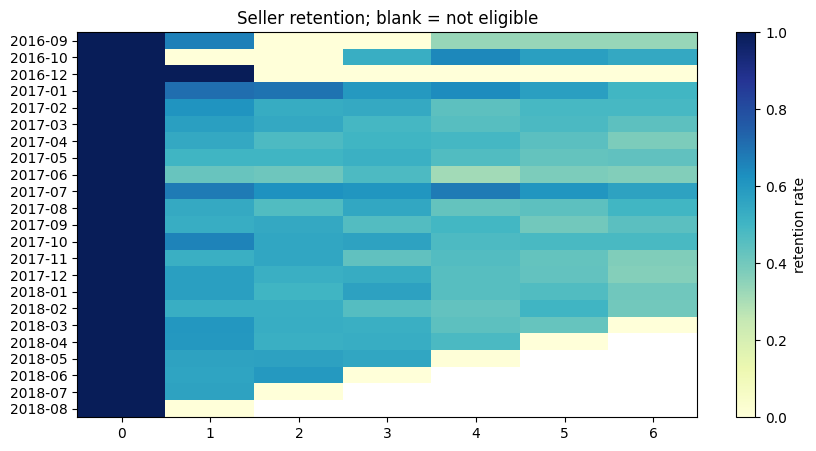

,cohort_month,age_month,eligible_flag,cohort_sellers,retained_sellers,retention_rate
0,2016-09,0,1,3,3.0,1.000000
1,2016-09,1,1,3,2.0,0.666667
2,2016-09,2,1,3,0.0,0.000000
3,2016-09,3,1,3,0.0,0.000000
4,2016-09,4,1,3,1.0,0.333333
5,2016-09,5,1,3,1.0,0.333333
6,2016-09,6,1,3,1.0,0.333333
7,2016-10,0,1,141,141.0,1.000000
8,2016-10,1,1,141,0.0,0.000000
9,2016-10,2,1,141,0.0,0.000000


In [2]:
pivot = cohort.pivot(index='cohort_month', columns='age_month', values='retention_rate')
fig, ax = plt.subplots(figsize=(10,5))
im = ax.imshow(pivot, aspect='auto', vmin=0, vmax=1, cmap='YlGnBu')
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
ax.set_title('Seller retention; blank = not eligible')
fig.colorbar(im, ax=ax, label='retention rate'); plt.show()
display(cohort.head(20))


## Takeaways

Compare only eligible cohort-age cells.
